# **Strategy Optimization**

**Importing classes and data:**

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
from itertools import product

In [4]:
class SMABackTester():      # Creating a class
  def __init__(self,company_symbol,period,interval,SMA_S,SMA_L):
    self.company_symbol=company_symbol
    self.period=period
    self.interval=interval
    self.SMA_S=SMA_S
    self.SMA_L=SMA_L
    self.result={}
    self.get_data()
    self.calculate_data()

  # Method: get_data()
  def get_data(self):
    stock=yf.download(tickers=self.company_symbol,period=self.period,interval= self.interval,auto_adjust=True)
    self.df=pd.DataFrame(stock["Close"])

  # Method: calculate_date():
  def calculate_data(self):
    for symbol in self.company_symbol:
      self.df[f"LR {symbol}"]=np.log(self.df[symbol]/self.df[symbol].shift(1))
      self.df[f"SMA_L {symbol}"]=self.df[symbol].rolling(window=self.SMA_L).mean()
      self.df[f"SMA_S {symbol}"]=self.df[symbol].rolling(window=self.SMA_S).mean()
      self.df.dropna(inplace=True)
      self.result[symbol] = self.df
    return self.df.dropna()

  # Method: set_parameters():Will be used for multiple combination of SMA_S & SMA_L
  def set_SMA_SnL(self,SMA_S=None,SMA_L=None):
    if self.SMA_S is not None:
      self.SMA_S=SMA_S
    if self.SMA_L is not None:
      self.SMA_L=SMA_L
    self.calculate_data()

  # Method: test_strategy(): will test the position and strategy for all SMA_S & SMA_L combination.
  def test_strategy(self):
    for symbol in self.company_symbol:
      self.df[f"Position {symbol}"]=np.where(self.df[f"SMA_S {symbol}"]>self.df[f"SMA_L {symbol}"],1,-1)
      self.df[f"Strategy {symbol}"]=self.df[f"Position {symbol}"].shift(1)*self.df[f"LR {symbol}"]
      self.df.dropna(inplace=True)
      self.df[f"Cumulative Return {symbol}"]=np.exp(self.df[f"LR {symbol}"].cumsum())
      self.df[f"Cumulative Strategy {symbol}"]=np.exp(self.df[f"Strategy {symbol}"].cumsum())
    return self.df.dropna()

  # Method: plot_result(): Will plot the results of the strategy for every ticker symbol
  def plot_result(self,ticker=None):
    if ticker is None:
      to_plot=self.company_symbol
    elif isinstance(ticker,str):
      to_plot=[ticker]
    else:
      to_plot=ticker
    for symbol in to_plot:
      if self.df[symbol] is None:
        print(f"Run the test_strategy() for {symbol} 1st!")
      else:
        fig,(ax1,ax2)=plt.subplots(2,1,figsize=(12,8),sharex=True)
        ax1.plot(self.df.index, self.df[symbol], label="Price", alpha=0.5)
        ax1.plot(self.df.index, self.df[f"SMA_S {symbol}"], label=f"SMA_S ({self.SMA_S})", color="orange")
        ax1.plot(self.df.index, self.df[f"SMA_L {symbol}"], label=f"SMA_L ({self.SMA_L})", color="blue")
        ax1.set_title(f"{symbol} - SMA Crossover")
        ax1.set_ylabel("Price")
        ax1.legend()
        ax2.plot(self.df.index, self.df[f"Cumulative Strategy {symbol}"], label="Strategy Performance", color="green")
        ax2.plot(self.df.index, self.df[f"Cumulative Return {symbol}"], label="Buy & Hold", color="gray", linestyle="--")
        ax2.set_ylabel("Growth ($1 Invested)")
        ax2.legend()
        plt.show()

  # Method: optimize_para(): make combination of SMA_S & SMA_L for different strategy output check
  def optimize_para(self,SMA_S_range,SMA_L_range):
    # making the combinations
    combination=list(product(range(*SMA_S_range),range(*SMA_L_range)))
    performance=[]
    for comb in combination:
      s,l=comb
      if s>l:
        continue
      self.set_parameters(s,l)
      # Access the result for the first company symbol and get the last 'Cumulative Strategy' value
      # Assuming optimization is based on the first company in the list
      df_first_company_result = self.test_strategy()[self.company_symbol[0]]
      performance.append(df_first_company_result["Cumulative Strategy"].iloc[-1])
    best_perf=np.max(performance)    # find best score
    opt=combination[np.argmax(performance)]    # find the SMA_S & SMA_L which gave the best score
    # Testing the best strategy by using optimal parameter (SMA_S & SMA_L)
    self.set_parameters(opt[0],opt[1])
    self.test_strategy()
    return self.performance

class BolingerBands():
  def __init__(self, company,period,interval,SMA_window,st_dev):
    self.company=company
    self.period=period
    self.interval=interval
    self.SMA_window=SMA_window
    self.st_dev=st_dev
    self.get_data()

  def get_data(self):
    data=yf.download(self.company,period=self.period,interval=self.interval,auto_adjust=True)
    self.df=pd.DataFrame(data["Close"])
    return self.df

  def calculate_data(self):
    ptc=0.0004
    for ticker in self.company:
      self.df[f"LR {ticker}"]=np.log(self.df[ticker]/self.df[ticker].shift(1))
      self.df[f"SMA {ticker}"]=self.df[ticker].rolling(self.SMA_window).mean()
      # Corrected Bollinger Band calculation:
      self.df[f"Lower {ticker}"]=self.df[f"SMA {ticker}"] - (self.df[ticker].rolling(self.SMA_window).std()*self.st_dev)
      self.df[f"Upper {ticker}"]=self.df[f"SMA {ticker}"] + (self.df[ticker].rolling(self.SMA_window).std()*self.st_dev)
      self.df[f"Distance {ticker}"]=self.df[ticker]-self.df[f"SMA {ticker}"]
      conditions = [self.df[ticker] < self.df[f"Lower {ticker}"], # Buy if price is below the lower band
          self.df[ticker] > self.df[f"Upper {ticker}"] ] # Sell if price is above the upper band
      choices = [1, -1] # Corresponding choices for the conditions
      self.df[f"Position {ticker}"] = np.select(conditions, choices, default=0) # Default to 0 (neutral) if no conditions met

      self.df[f"Strategy {ticker}"]=self.df[f"Position {ticker}"].shift(1)*self.df[f"LR {ticker}"]
      self.df[f"Cumulative Return {ticker}"]=np.exp(self.df[f"LR {ticker}"].cumsum())
      self.df[f"Cumulative Strategy {ticker}"]=np.exp(self.df[f"Strategy {ticker}"].cumsum())
      self.df[f"Trades {ticker}"]=self.df[f"Position {ticker}"].diff().fillna(0).abs()
      self.df[f"Net_Strategy {ticker}"]=self.df[f"Strategy {ticker}"]-self.df[f"Trades {ticker}"]*ptc
      self.df[f"Cumulative Net_Strategy {ticker}"]=np.exp(self.df[f"Net_Strategy {ticker}"].cumsum())
    return self.df.dropna()

  def plot_data(self):
    for ticker in self.company:
      self.df[[f"{ticker}",f"SMA {ticker}",f"Lower {ticker}",f"Upper {ticker}"]].plot(figsize=(15,6),fontsize=12)
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Return {ticker}",f"Cumulative Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Strategy {ticker}",f"Cumulative Net_Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()

  def ann_result(self):
    ann_return=[];ann_risk=[]
    for ticker in self.company:
      ann_return.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].mean()*(4*252))
      ann_risk.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].std()*np.sqrt(4*252))
    print(f"Annual Returns of companies = {ann_return}")
    print(f"Annual Risks of companies = {ann_risk}")

**Defining Function of Optimizing strategies:**

In [5]:
def optimize_stratetgy(params,display_df=None):
  sma_s,sma_l,sma_window,St_dev = params
  timegap="1y";timeframe="4h"
  symbol=["BTC-USD"];trading_cost=0.0004
  # SMA
  test1=SMABackTester(company_symbol=symbol,period=timegap,interval=timeframe,SMA_S=int(sma_s),SMA_L=int(sma_l))
  test1.test_strategy()
  # Bollinger Bands
  test2=BolingerBands(company=symbol,period=timegap,interval=timeframe,SMA_window=int(sma_window),st_dev=int(St_dev))
  test2.calculate_data()
  # combine signals and returns (with taking account of busy trading hours)
  comb=test1.df.loc[:,[f"LR {symbol[0]}",f"Position {symbol[0]}"]]
  comb.rename(columns={f"Position {symbol[0]}":f"Position {symbol[0]} SMA"},inplace=True)
  comb["IST"]=comb.index.tz_convert("Asia/Kolkata")
  comb["Hour"]=comb["IST"].dt.hour
  comb[f"Position {symbol[0]} BB"]=test2.df[f'Position {symbol[0]}']
  comb[f"Position {symbol[0]} Combine"]=np.sign(comb[f'Position {symbol[0]} BB']+comb[f'Position {symbol[0]} SMA'])
  # comb[f'Position {symbol[0]} Combine']=np.where(comb['Hour'].between(10,14),comb[f"Position {symbol[0]} Combine"],0)
  # Backtesting
  comb[f"Trades {symbol[0]}"]=comb[f"Position {symbol[0]} Combine"].diff().abs()
  comb[f"Strategy {symbol[0]}"]=(comb[f"Position {symbol[0]} Combine"].shift(1)*comb[f"LR {symbol[0]}"])-(comb[f"Trades {symbol[0]}"]*trading_cost)
  comb[f"C_returns {symbol[0]}"]=np.exp(comb[f"LR {symbol[0]}"].cumsum())
  comb[f"C_strategy {symbol[0]}"]=np.exp(comb[f"Strategy {symbol[0]}"].cumsum())
  if display_df==True:
    return comb
  else:
    return float(-comb[f"C_strategy {symbol[0]}"].iloc[-1])

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


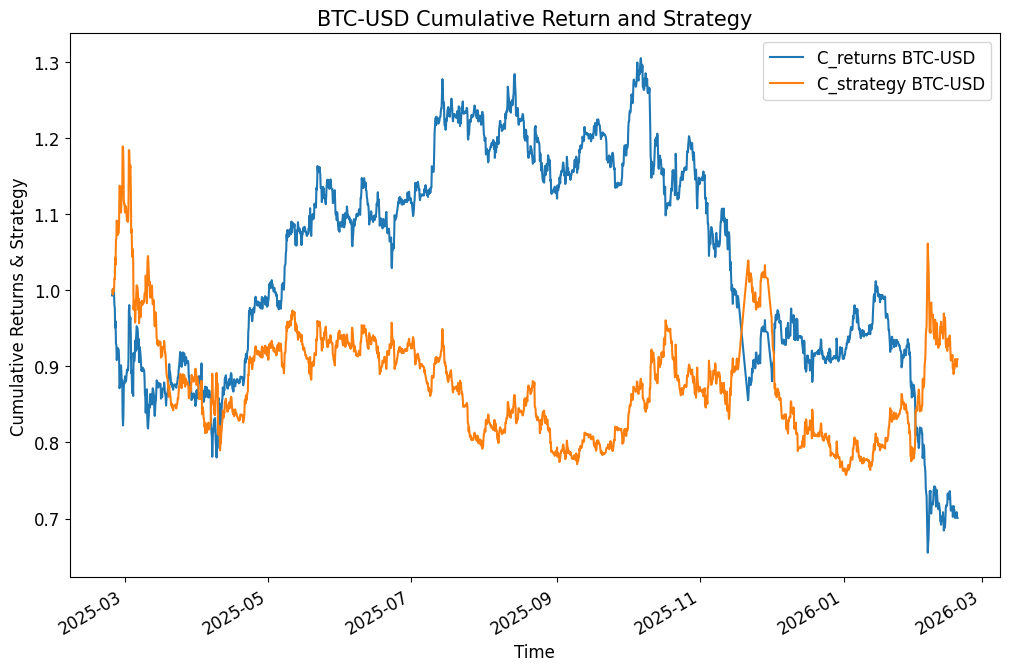

In [6]:
df=optimize_stratetgy((7,30,7,2),display_df=True)
df[['C_returns BTC-USD','C_strategy BTC-USD']].plot(figsize=(12,8),fontsize=12)
plt.xlabel("Time",fontsize=12);plt.ylabel("Cumulative Returns & Strategy",fontsize=12)
plt.title("BTC-USD Cumulative Return and Strategy",fontsize=15)
plt.legend(fontsize=12);plt.show()

**Optimizing Parameters form the range of parameters:**

In [7]:
from scipy.optimize import minimize

In [8]:
# bands=(sma_s range,sma_l range,sma_window range, st_dev range)
bands=((5,20),(20,100),(5,20),(2,5))
start=(7,30,7,2)
optz=minimize(optimize_stratetgy,start,method="Powell",bounds=bands)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [9]:
optz.x
# As we got the best parameters we now updated the return code in optimize_strategy

array([10.72952517, 49.15112875, 19.99994474,  4.29185735])

**Covnerting into dataframe with best parameters obtained from `optz.x`**

In [10]:
df=optimize_stratetgy(optz.x,display_df=True)
df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,LR BTC-USD,Position BTC-USD SMA,IST,Hour,Position BTC-USD BB,Position BTC-USD Combine,Trades BTC-USD,Strategy BTC-USD,C_returns BTC-USD,C_strategy BTC-USD
Datetime,,,,,,,,,,
2025-02-26 16:00:00+00:00,-0.042753,-1,2025-02-26 21:30:00+05:30,21,0,-1,NaN,NaN,0.958148,NaN
2025-02-26 20:00:00+00:00,0.002841,-1,2025-02-27 01:30:00+05:30,1,0,-1,0.0,-0.002841,0.960873,0.997163
2025-02-27 00:00:00+00:00,0.013849,-1,2025-02-27 05:30:00+05:30,5,0,-1,0.0,-0.013849,0.974274,0.983448
2025-02-27 04:00:00+00:00,0.012731,-1,2025-02-27 09:30:00+05:30,9,0,-1,0.0,-0.012731,0.986756,0.971008
2025-02-27 08:00:00+00:00,0.004449,-1,2025-02-27 13:30:00+05:30,13,0,-1,0.0,-0.004449,0.991156,0.966697
...,...,...,...,...,...,...,...,...,...,...
2026-02-17 20:00:00+00:00,-0.004203,-1,2026-02-18 01:30:00+05:30,1,0,-1,0.0,0.004203,0.772273,1.161804
2026-02-18 00:00:00+00:00,0.001919,-1,2026-02-18 05:30:00+05:30,5,0,-1,0.0,-0.001919,0.773756,1.159576
2026-02-18 04:00:00+00:00,0.006863,-1,2026-02-18 09:30:00+05:30,9,0,-1,0.0,-0.006863,0.779085,1.151645


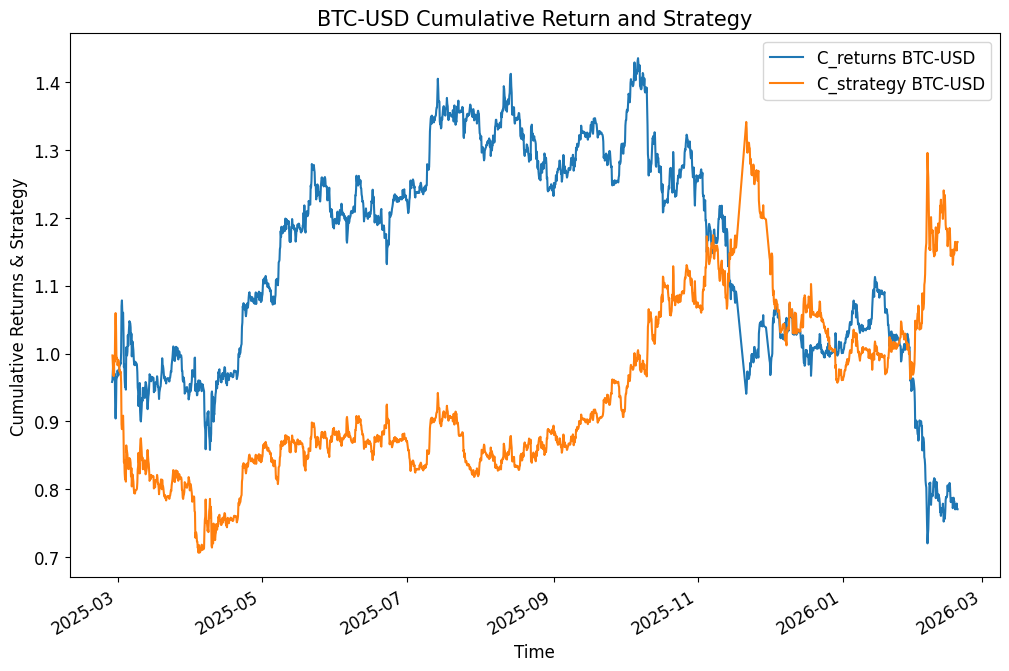

In [11]:
df[['C_returns BTC-USD','C_strategy BTC-USD']].plot(figsize=(12,8),fontsize=12)
plt.xlabel("Time",fontsize=12);plt.ylabel("Cumulative Returns & Strategy",fontsize=12)
plt.title("BTC-USD Cumulative Return and Strategy",fontsize=15)
plt.legend(fontsize=12);plt.show()